# Расклинивающее давление через контактную теорему

Ноутбук считает нормальное давление на стенку по **полной** силе, с которой жидкость действует на стенку.

$$P_N = \underbrace{k_BT \sum_i n_i(r_i)}_{\text{жёсткая стенка (контакт)}} \; - \; \underbrace{f_s}_{\text{кулон на атомах стенки}}, \qquad \Pi = P_N - P_b$$

* $n_i(r_i)$ это контактная плотность сайта $i$ (Na, Cl, Ip, Im, G) у плоскости жёсткой стенки $z = r_i$, усреднённая по двум стенкам. Получается экстраполяцией профиля к контакту.
* $f_s$ это колонка `solvation_force` из `simulation_data.csv`, то есть $(\sum F_z^{Wb} - \sum F_z^{Wt}) / 2A$. Знак такой, что $f_s > 0$ означает, что стенку тянет внутрь поры. Поэтому в $P_N$ она входит с минусом. **Модуль не берём.**
* $P_b$ это давление объёмного раствора. Резервуара в NVT нет, поэтому оно оценивается по центру поры в идеальном приближении: $c_{s,b} = \sqrt{n_+ n_-}$ (в центре поле равно нулю), $c_{z,b} = n_G$, $P_b \approx k_BT\,(2c_{s,b} + c_{z,b})$.
* Для контроля считается $k_BT\sum n(\text{центр})$ (Na, Cl и молекулы цвиттерионов). В двойном слое, где доминируют противоионы, эта величина должна быть близка к $P_N$.
* Для размазанного заряда кулоновская сила на стенку в нейтральной системе строго равна $\sigma^2/(2\varepsilon_0\varepsilon)$. Отклонение $f_s$ от этой величины показывает вклад дискретности зарядов стенки.

Запускать из `~/AntiDLVO` на кластере, лучше на вычислительном узле: чтение траекторий занимает минуты на расчёт. Гистограммы кэшируются в `pressure_contact_cache.npz` внутри папки расчёта, так что повторный запуск быстрый. Кэш сам пересобирается, если траектория обновилась.

In [1]:
import os, os.path as osp, glob, io, re, time
from collections import deque
from itertools import islice
from multiprocessing import Pool

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# ---------------- параметры ----------------
RESULTS_ROOT   = "results_prod_neutral"
PZ_DIRS        = {"pz_17": 17.0, "pz_27p6": 27.6}
SWEEPS         = ["H", "sigma", "C", "Cz"]

START_FRAME    = 2000     # отбрасываем уравновешивание (кадр = 50 шагов)
STRIDE         = 5        # берём каждый 5-й кадр (соседние кадры сильно коррелированы)
N_BLOCKS       = 5        # блочное усреднение для погрешностей
MIN_ROWS       = 10000    # расчёты короче этого (ещё идут) пропускаем
BIN            = 0.005    # нм, ширина бина по расстоянию до плоскости контакта
FIT_BINS       = 8        # число бинов у контакта для линейной экстраполяции n(d) -> d=0
MID_HALF_WIDTH = 0.25     # нм, полуширина окна «центр поры»
N_JOBS         = 8        # параллельных процессов на построение кэша
REBUILD_CACHE  = False

SITES   = ["Na", "Cl", "Ip", "Im", "G"]          # сайты с жёсткой стенкой
CACHE   = "pressure_contact_cache.npz"
CACHE_VERSION = 1

# ---------------- константы ----------------
T        = 298.0
KT       = 8.314462618e-3 * T         # кДж/моль
TO_MPA   = 1.66053907                 # 1 кДж/моль/нм^3 = 1.6605 МПа
EPS0     = 8.8541878128e-12
EPS_W    = 78.0
E_CHARGE = 1.602176634e-19
R_DEFAULT = {"Na": 0.331, "Cl": 0.383}


## Вспомогательные функции

In [2]:
def parse_folder(name):
    """Параметры из имени папки ions_dipole_<sweep>_pz_<pz>_H_<H>_sigma_<s>_C_<C>_Cz_<Cz>_<date>_<time>."""
    out = {}
    for key, pat in [("pz", r"_pz_([0-9p.]+)_"), ("H", r"_H_([-0-9.]+)_"),
                     ("sigma", r"_sigma_([-0-9.]+)_"), ("C", r"_C_([-0-9.]+)_"),
                     ("Cz", r"_Cz_([-0-9.]+)_")]:
        m = re.search(pat, name)
        if m:
            out[key] = float(m.group(1).replace("p", "."))
    return out


def site_radii(pz):
    """Радиусы жёсткой стенки для сайтов, как в configs_prod/ions_dipole.yaml."""
    r = dict(R_DEFAULT)
    r["Ip"] = r["Na"]
    r["Im"] = r["Cl"]
    r["G"] = pz / 48.032047 / 2.0
    return r


def radii_from_config(calc_dir, pz):
    """Берём r_* из config_backup.yaml, если они там числами; иначе значения по умолчанию."""
    r = site_radii(pz)
    path = osp.join(calc_dir, "config_backup.yaml")
    try:
        import yaml
        with open(path) as f:
            cfg = yaml.safe_load(f) or {}
        for s in SITES:
            v = cfg.get(f"r_{s}")
            if isinstance(v, (int, float)):
                r[s] = float(v)
    except Exception:
        pass
    return r


def count_rows(csv_path):
    with open(csv_path) as f:
        return sum(1 for _ in f) - 1


def _skip_lines(f, n):
    deque(islice(f, n), maxlen=0)


def build_cache(calc_dir, pz):
    """Один проход по trajectory.xyz. Гистограммы расстояния до плоскости контакта по блокам."""
    traj = osp.join(calc_dir, "trajectory.xyz")
    cache_path = osp.join(calc_dir, CACHE)
    if (not REBUILD_CACHE and osp.isfile(cache_path)
            and osp.getmtime(cache_path) >= osp.getmtime(traj)):
        with np.load(cache_path, allow_pickle=True) as d:
            if int(d.get("version", 0)) == CACHE_VERSION and int(d["start_frame"]) == START_FRAME \
                    and int(d["stride"]) == STRIDE and float(d["bin"]) == BIN \
                    and int(d["n_blocks"]) == N_BLOCKS:
                return cache_path

    radii = radii_from_config(calc_dir, pz)
    t0 = time.time()

    # число кадров: считаем по csv (1 строка = 1 кадр при log_interval = xyz_interval)
    n_rows = count_rows(osp.join(calc_dir, "simulation_data.csv"))

    with open(traj) as f:
        # первый кадр: состав, коробка, стенка
        n_atoms = int(f.readline())
        header = f.readline()
        lat = re.search(r'Lattice="([^"]+)"', header).group(1).split()
        Lx, Ly, H = float(lat[0]), float(lat[4]), float(lat[8])
        first = list(islice(f, n_atoms))
        species = np.array([ln.split(None, 1)[0] for ln in first])
        charges = np.array([float(ln.split()[4]) for ln in first])
        n_wb = int(np.sum(species == "Wb"))
        q_wb = float(np.sum(charges[species == "Wb"]))

        masks = {s: species == s for s in SITES if np.any(species == s)}
        nbins = {s: int(np.ceil((H / 2 - radii[s]) / BIN)) for s in masks}
        hist = {s: np.zeros((N_BLOCKS, nbins[s])) for s in masks}
        frames_in_block = np.zeros(N_BLOCKS, dtype=int)

        n_total = max(n_rows, START_FRAME + 1)
        block_len = max((n_total - START_FRAME) / N_BLOCKS, 1)

        k = 1  # первый кадр уже прочитан (он в уравновешивании)
        while True:
            line = f.readline()
            if not line:
                break
            if not line.strip():
                continue
            n = int(line)
            f.readline()
            if n != n_atoms:
                raise RuntimeError(f"{calc_dir}: число атомов меняется (кадр {k})")
            if k >= START_FRAME and (k - START_FRAME) % STRIDE == 0:
                block = list(islice(f, n))
                if len(block) < n:
                    break
                z = pd.read_csv(io.StringIO("".join(block)), sep=r"\s+", header=None,
                                usecols=[3], engine="c").values[:, 0]
                b = min(int((k - START_FRAME) / block_len), N_BLOCKS - 1)
                for s, m in masks.items():
                    zs = z[m]
                    d = np.minimum(zs, H - zs) - radii[s]
                    h, _ = np.histogram(d, bins=nbins[s], range=(0.0, nbins[s] * BIN))
                    hist[s][b] += h
                frames_in_block[b] += 1
            else:
                _skip_lines(f, n)
            k += 1

    np.savez(cache_path, version=CACHE_VERSION, start_frame=START_FRAME, stride=STRIDE,
             bin=BIN, n_blocks=N_BLOCKS, Lx=Lx, Ly=Ly, H=H, n_wb=n_wb, q_wb=q_wb,
             n_frames_total=k, frames_in_block=frames_in_block,
             sites=np.array(list(masks)), radii=np.array([radii[s] for s in masks]),
             counts=np.array([int(masks[s].sum()) for s in masks]),
             **{f"hist_{s}": hist[s] for s in masks})
    print(f"  cache {osp.basename(calc_dir)}: {k} frames, {time.time() - t0:.0f} s", flush=True)
    return cache_path


def _build_cache_job(args):
    try:
        return build_cache(*args), None
    except Exception as e:
        return None, f"{args[0]}: {e!r}"


## Список расчётов и построение кэша

In [3]:
runs = []
for pz_dir, pz in PZ_DIRS.items():
    for sweep in SWEEPS:
        for calc_dir in sorted(glob.glob(osp.join(RESULTS_ROOT, pz_dir, sweep, "*"))):
            if not osp.isdir(calc_dir):
                continue
            traj = osp.join(calc_dir, "trajectory.xyz")
            csv = osp.join(calc_dir, "simulation_data.csv")
            if not (osp.isfile(traj) and osp.isfile(csv)):
                print("нет файлов:", calc_dir)
                continue
            rows = count_rows(csv)
            if rows < MIN_ROWS:
                print(f"пропуск (идёт, {rows} строк):", calc_dir)
                continue
            p = parse_folder(osp.basename(calc_dir))
            runs.append(dict(pz=pz, pz_dir=pz_dir, sweep=sweep, calc_dir=calc_dir,
                             real_dir=osp.realpath(calc_dir), rows=rows, **{k: p.get(k) for k in ["H", "sigma", "C", "Cz"]}))

runs = pd.DataFrame(runs)
print(f"{len(runs)} записей, {runs.real_dir.nunique()} уникальных расчётов")
runs[["pz", "sweep", "H", "sigma", "C", "Cz", "rows"]]


25 записей, 25 уникальных расчётов


,pz,sweep,H,sigma,C,Cz,rows
0,17.0,H,11.0,-20.0,0.01,0.1,20000
1,17.0,H,3.0,-20.0,0.01,0.1,20000
2,17.0,H,5.0,-20.0,0.01,0.1,20000
3,17.0,H,7.0,-20.0,0.01,0.1,20000
4,17.0,H,9.0,-20.0,0.01,0.1,20000
5,17.0,sigma,3.0,-10.0,0.01,0.1,20000
6,17.0,sigma,3.0,-15.0,0.01,0.1,20000
7,17.0,sigma,3.0,-20.0,0.01,0.1,20000
8,17.0,sigma,3.0,-5.0,0.01,0.1,20000
9,17.0,sigma,3.0,0.0,0.01,0.1,20000


In [4]:
unique = runs.drop_duplicates("real_dir")
jobs = [(r.real_dir, r.pz) for r in unique.itertuples()]
t0 = time.time()
with Pool(min(N_JOBS, len(jobs))) as pool:
    res = pool.map(_build_cache_job, jobs)
errors = [e for _, e in res if e]
print(f"готово за {time.time() - t0:.0f} s; ошибок: {len(errors)}")
for e in errors:
    print(" ", e)


  cache ions_dipole_sigma_pz_17_H_3_sigma_-10_C_0.01_Cz_0.1_20260216_125433: 20000 frames, 137 s
  cache ions_dipole_sigma_pz_17_H_3_sigma_-15_C_0.01_Cz_0.1_20260216_125433: 20000 frames, 184 s
  cache ions_dipole_sigma_pz_17_H_3_sigma_0_C_0.01_Cz_0.1_20260216_163305: 20000 frames, 32 s
  cache ions_dipole_sigma_pz_17_H_3_sigma_-5_C_0.01_Cz_0.1_20260216_125433: 20000 frames, 85 s
  cache ions_dipole_H_pz_17_H_3_sigma_-20_C_0.01_Cz_0.1_20260216_143617: 20000 frames, 239 s
  cache ions_dipole_sigma_pz_17_H_3_sigma_-20_C_0.01_Cz_0.1_20260216_133324: 20000 frames, 240 s
  cache ions_dipole_H_pz_17_H_5_sigma_-20_C_0.01_Cz_0.1_20260216_125433: 20000 frames, 256 s
  cache ions_dipole_H_pz_17_H_7_sigma_-20_C_0.01_Cz_0.1_20260216_125433: 20000 frames, 272 s
  cache ions_dipole_H_pz_17_H_9_sigma_-20_C_0.01_Cz_0.1_20260216_125433: 20000 frames, 286 s
  cache ions_dipole_H_pz_17_H_11_sigma_-20_C_0.01_Cz_0.1_20260216_125433: 20000 frames, 302 s
  cache ions_dipole_C_pz_17_H_3_sigma_-20_C_0.01_Cz_0.

## Контактные плотности, кулон, давление

In [5]:
def contact_value(dens, fit_bins=FIT_BINS):
    """Линейная экстраполяция n(d) по первым fit_bins бинам к d = 0."""
    x = (np.arange(fit_bins) + 0.5) * BIN
    y = dens[:fit_bins]
    a, b = np.polyfit(x, y, 1)
    return b


def analyze(calc_dir):
    d = np.load(osp.join(calc_dir, CACHE), allow_pickle=True)
    A, H = float(d["Lx"] * d["Ly"]), float(d["H"])
    fb = d["frames_in_block"]
    sites = list(d["sites"])
    radii = dict(zip(sites, d["radii"]))
    ok = fb > 0

    # профили n(d) в нм^-3 по блокам: две стенки -> множитель 2
    dens = {s: d[f"hist_{s}"][ok] / (fb[ok, None] * 2 * A * BIN) for s in sites}

    # контакт по блокам
    n_contact = {s: np.array([contact_value(dens[s][b]) for b in range(ok.sum())]) for s in sites}
    p_contact_blocks = sum(KT * n_contact[s] for s in sites)            # кДж/моль/нм^3

    # центр поры: бины, у которых |z - H/2| < MID_HALF_WIDTH
    n_mid = {}
    for s in sites:
        nb = dens[s].shape[1]
        dist_to_mid = (H / 2 - radii[s]) - (np.arange(nb) + 0.5) * BIN
        sel = dist_to_mid < MID_HALF_WIDTH
        n_mid[s] = dens[s][:, sel].mean(axis=1)

    # кулон на стенке из csv, те же блоки по кадрам
    df = pd.read_csv(osp.join(calc_dir, "simulation_data.csv"))
    fs = df["solvation_force"].values[START_FRAME:]
    fs_blocks = np.array([blk.mean() for blk in np.array_split(fs, N_BLOCKS)])[ok]

    nNa = n_mid.get("Na", 0 * fs_blocks)
    nCl = n_mid.get("Cl", 0 * fs_blocks)
    nG = n_mid.get("G", 0 * fs_blocks)
    Pb_blocks = KT * (2 * np.sqrt(np.clip(nNa * nCl, 0, None)) + nG)
    Pmid_blocks = KT * (nNa + nCl + nG)

    PN_blocks = p_contact_blocks - fs_blocks
    Pi_blocks = PN_blocks - Pb_blocks

    sigma_C_m2 = float(d["q_wb"]) * E_CHARGE / (A * 1e-18)
    p_smeared = sigma_C_m2 ** 2 / (2 * EPS0 * EPS_W) / 1e6          # МПа

    def ms(x):
        x = np.asarray(x) * TO_MPA
        return x.mean(), (x.std(ddof=1) / np.sqrt(len(x)) if len(x) > 1 else np.nan)

    out = dict(H_box=H, sigma_eff=float(d["q_wb"]) * 16.0217663 / A,
               n_frames=int(d["n_frames_total"]), p_smeared=p_smeared)
    for name, arr in [("P_contact", p_contact_blocks), ("f_s", fs_blocks), ("P_N", PN_blocks),
                      ("P_b", Pb_blocks), ("P_mid_ideal", Pmid_blocks), ("Pi", Pi_blocks)]:
        out[name], out[name + "_err"] = ms(arr)
    for s in sites:
        out[f"Pc_{s}"] = float(np.mean(KT * n_contact[s]) * TO_MPA)
        out[f"nc_{s}"] = float(np.mean(n_contact[s]))
        out[f"nmid_{s}"] = float(np.mean(n_mid[s]))
    out["_dens"] = {s: dens[s].mean(axis=0) for s in sites}
    out["_radii"] = radii
    return out


results = {}
for r in unique.itertuples():
    try:
        results[r.real_dir] = analyze(r.real_dir)
    except Exception as e:
        print("ошибка анализа:", r.real_dir, repr(e))

rows = []
for r in runs.itertuples():
    if r.real_dir in results:
        res = {k: v for k, v in results[r.real_dir].items() if not k.startswith("_")}
        rows.append(dict(r._asdict(), **res))
table = pd.DataFrame(rows).drop(columns=["Index"])
table.to_csv("disjoining_pressure_contact.csv", index=False)

show = ["pz", "sweep", "H", "sigma", "C", "Cz", "sigma_eff", "P_contact", "f_s", "p_smeared",
        "P_N", "P_N_err", "P_mid_ideal", "P_b", "Pi", "Pi_err"]
pd.set_option("display.width", 200)
table[show].round(3)


,pz,sweep,H,sigma,C,Cz,sigma_eff,P_contact,f_s,p_smeared,P_N,P_N_err,P_mid_ideal,P_b,Pi,Pi_err
0,17.0,H,11.0,-20.0,0.01,0.1,-19.386,16.393,9.389,27.209,7.005,0.727,0.465,0.439,6.566,0.727
1,17.0,H,3.0,-20.0,0.01,0.1,-19.386,29.312,14.985,27.209,14.327,1.104,2.228,1.319,13.008,1.102
2,17.0,H,5.0,-20.0,0.01,0.1,-19.386,24.246,14.436,27.209,9.809,1.118,0.950,0.761,9.048,1.116
3,17.0,H,7.0,-20.0,0.01,0.1,-19.386,22.390,12.345,27.209,10.045,0.501,0.635,0.556,9.489,0.500
4,17.0,H,9.0,-20.0,0.01,0.1,-19.386,22.120,10.624,27.209,11.496,1.269,0.522,0.479,11.017,1.263
5,17.0,sigma,3.0,-10.0,0.01,0.1,-10.254,9.281,4.687,7.612,4.593,0.387,1.518,0.939,3.655,0.388
6,17.0,sigma,3.0,-15.0,0.01,0.1,-14.460,18.082,8.771,15.137,9.311,0.331,1.826,1.085,8.226,0.334
7,17.0,sigma,3.0,-20.0,0.01,0.1,-19.386,29.104,14.959,27.209,14.145,0.467,2.181,1.268,12.877,0.469
8,17.0,sigma,3.0,-5.0,0.01,0.1,-4.847,2.982,1.171,1.701,1.811,0.093,1.075,0.707,1.104,0.093
9,17.0,sigma,3.0,0.0,0.01,0.1,0.000,0.453,0.000,0.000,0.453,0.012,0.399,0.399,0.054,0.013


## Проверки

1. **Кулон против размазанного заряда.** Для нейтральной системы $f_s \approx \sigma_{\rm eff}^2/(2\varepsilon_0\varepsilon)$. Отношение, близкое к 1, говорит о том, что `solvation_force` логируется корректно. Отклонение показывает эффект дискретности.
2. **Два пути к $P_N$.** Контактная теорема против $k_BT\sum n(\text{центр})$.
3. **Повторы базовой точки** 17 D (H = 3, σ = −20, C = 0.01, C_z = 0.1) из четырёх свипов. Их разброс даёт честную оценку погрешности.

In [6]:
chk = table.drop_duplicates("real_dir").copy()
chk["f_s / smeared"] = chk["f_s"] / chk["p_smeared"]
chk["P_N / P_mid_ideal"] = chk["P_N"] / chk["P_mid_ideal"]
display(chk[["pz", "sweep", "H", "sigma", "C", "Cz", "f_s", "p_smeared", "f_s / smeared",
             "P_N", "P_mid_ideal", "P_N / P_mid_ideal"]].round(3))

base = table[(table.H == 3) & (table.sigma == -20) & (table.C == 0.01) & (table.Cz == 0.1)] \
    .drop_duplicates("real_dir")
print("Повторы базовой точки:")
display(base[["pz", "sweep", "P_contact", "f_s", "P_N", "P_N_err", "P_b", "Pi", "Pi_err"]].round(4))
for pz, g in base.groupby("pz"):
    if len(g) > 1:
        print(f"p_z = {pz}: Pi = {g.Pi.mean():.4f} ± {g.Pi.std(ddof=1)/np.sqrt(len(g)):.4f} МПа "
              f"(разброс по {len(g)} повторам)")


,pz,sweep,H,sigma,C,Cz,f_s,p_smeared,f_s / smeared,P_N,P_mid_ideal,P_N / P_mid_ideal
0,17.0,H,11.0,-20.0,0.01,0.1,9.389,27.209,0.345,7.005,0.465,15.075
1,17.0,H,3.0,-20.0,0.01,0.1,14.985,27.209,0.551,14.327,2.228,6.432
2,17.0,H,5.0,-20.0,0.01,0.1,14.436,27.209,0.531,9.809,0.950,10.321
3,17.0,H,7.0,-20.0,0.01,0.1,12.345,27.209,0.454,10.045,0.635,15.808
4,17.0,H,9.0,-20.0,0.01,0.1,10.624,27.209,0.390,11.496,0.522,22.011
5,17.0,sigma,3.0,-10.0,0.01,0.1,4.687,7.612,0.616,4.593,1.518,3.026
6,17.0,sigma,3.0,-15.0,0.01,0.1,8.771,15.137,0.579,9.311,1.826,5.100
7,17.0,sigma,3.0,-20.0,0.01,0.1,14.959,27.209,0.550,14.145,2.181,6.486
8,17.0,sigma,3.0,-5.0,0.01,0.1,1.171,1.701,0.689,1.811,1.075,1.684
9,17.0,sigma,3.0,0.0,0.01,0.1,0.000,0.000,NaN,0.453,0.399,1.135


Повторы базовой точки:


,pz,sweep,P_contact,f_s,P_N,P_N_err,P_b,Pi,Pi_err
1,17.0,H,29.3119,14.9848,14.3271,1.1036,1.3188,13.0083,1.1021
7,17.0,sigma,29.1036,14.9590,14.1446,0.4671,1.2678,12.8769,0.4694
10,17.0,C,31.0679,14.9521,16.1158,0.8324,1.3429,14.7729,0.8215
13,17.0,Cz,27.9130,15.0581,12.8549,1.8447,1.3334,11.5215,1.8494


p_z = 17.0: Pi = 13.0449 ± 0.6669 МПа (разброс по 4 повторам)


## Профили у контакта (контроль экстраполяции)

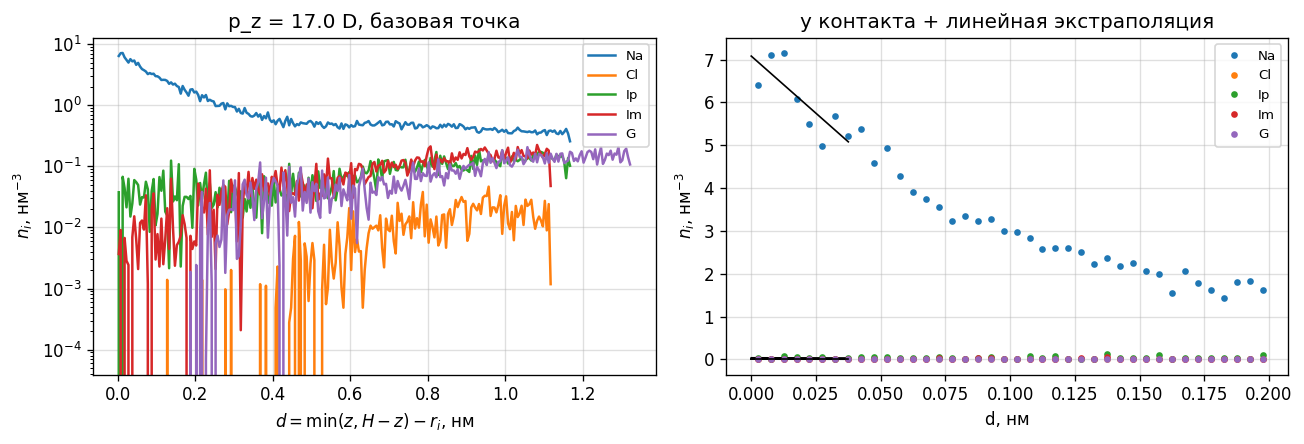

In [7]:
def pick(pz, H=3, sigma=-20, C=0.01, Cz=0.1):
    g = table[(table.pz == pz) & (table.H == H) & (table.sigma == sigma) & (table.C == C) & (table.Cz == Cz)]
    return None if g.empty else g.iloc[0].real_dir

for pz in PZ_DIRS.values():
    rd = pick(pz)
    if rd is None:
        continue
    res = results[rd]
    fig, axes = plt.subplots(1, 2, figsize=(11, 3.8), dpi=120)
    for s, n in res["_dens"].items():
        x = (np.arange(len(n)) + 0.5) * BIN
        axes[0].plot(x, n, label=s)
        xf = x[:FIT_BINS]
        a, b = np.polyfit(xf, n[:FIT_BINS], 1)
        axes[1].plot(x[:40], n[:40], "o", ms=3, label=s)
        axes[1].plot([0, xf[-1]], [b, a * xf[-1] + b], "k-", lw=1)
    axes[0].set(xlabel=r"$d = \min(z, H-z) - r_i$, нм", ylabel=r"$n_i$, нм$^{-3}$", yscale="log",
                title=f"p_z = {pz} D, базовая точка")
    axes[1].set(xlabel="d, нм", ylabel=r"$n_i$, нм$^{-3}$", title="у контакта + линейная экстраполяция")
    for ax in axes:
        ax.grid(alpha=0.4); ax.legend(fontsize=8)
    plt.tight_layout(); plt.show()


## Баланс вкладов в базовой точке

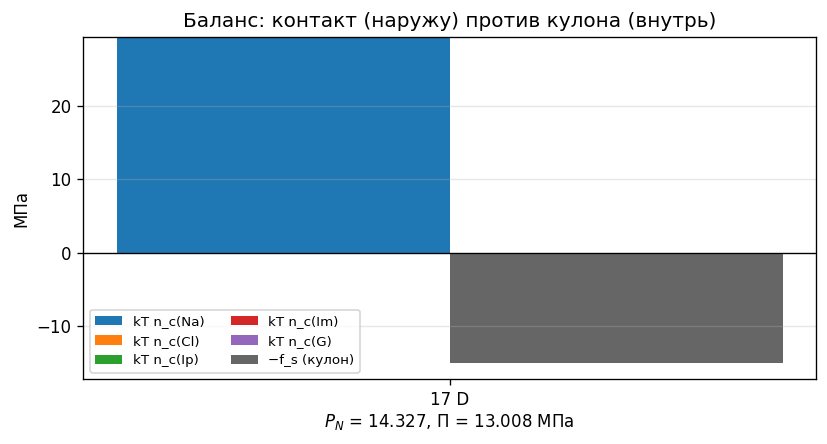

In [8]:
fig, ax = plt.subplots(figsize=(7, 3.8), dpi=120)
labels, width = [], 0.35
for i, pz in enumerate(PZ_DIRS.values()):
    rd = pick(pz)
    if rd is None:
        continue
    row = table[table.real_dir == rd].iloc[0]
    parts = {s: row.get(f"Pc_{s}", 0.0) for s in SITES}
    parts = {k: (0.0 if pd.isna(v) else v) for k, v in parts.items()}
    bottom = 0.0
    for s, v in parts.items():
        ax.bar(i, v, width, bottom=bottom, label=f"kT n_c({s})" if i == 0 else None)
        bottom += v
    ax.bar(i + width, -row.f_s, width, color="k", alpha=0.6, label="−f_s (кулон)" if i == 0 else None)
    labels.append((i + width / 2, f"{pz:g} D\n$P_N$ = {row.P_N:.3f}, Π = {row.Pi:.3f} МПа"))
ax.axhline(0, color="k", lw=0.8)
ax.set_xticks([x for x, _ in labels], [l for _, l in labels])
ax.set_ylabel("МПа"); ax.legend(fontsize=8, ncol=2, loc="lower left"); ax.grid(alpha=0.3, axis="y")
ax.set_title("Баланс: контакт (наружу) против кулона (внутрь)")
plt.tight_layout(); plt.show()


## Π по свипам

Сплошная линия это $\Pi = P_N - P_b$, пунктир это $P_N$ без вычета оценки объёмного давления. Погрешности из блочного усреднения (стандартная ошибка по $N_{\rm blocks}$ блокам).

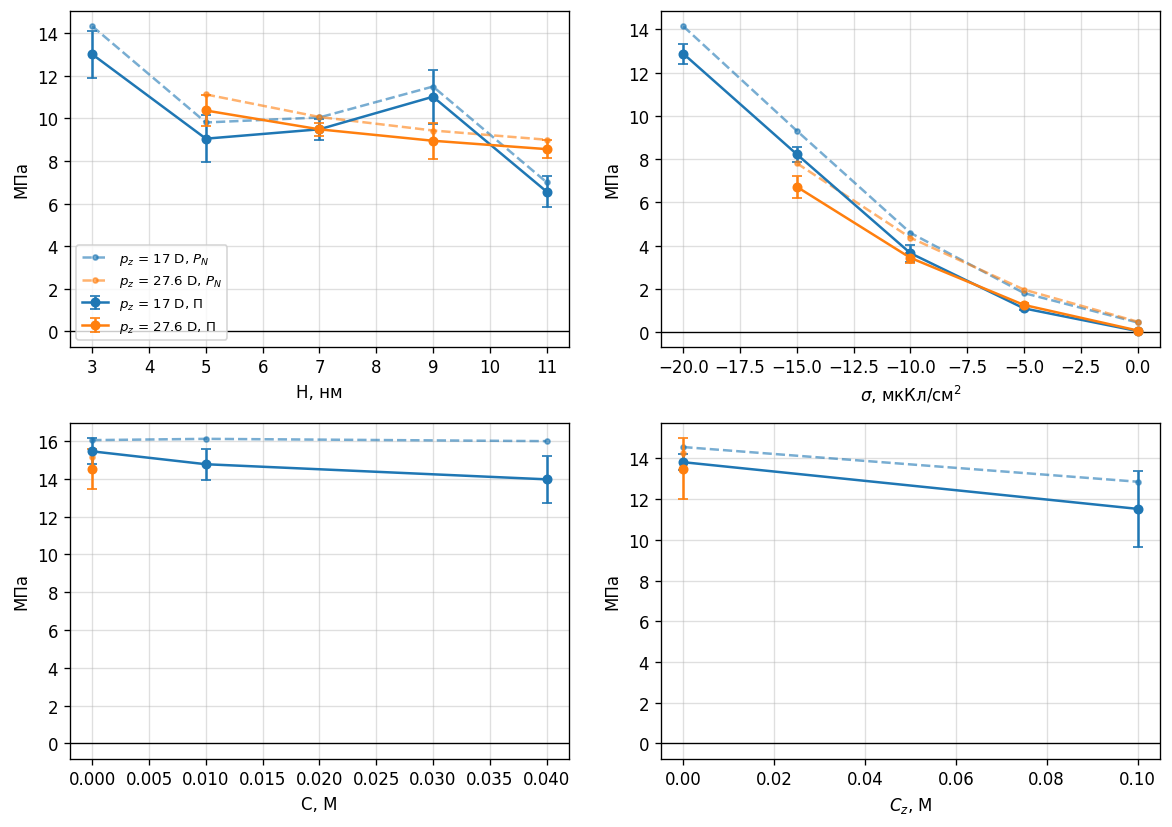

In [9]:
XLAB = {"H": "H, нм", "sigma": r"$\sigma$, мкКл/см$^2$", "C": "C, М", "Cz": r"$C_z$, М"}
COLORS = {17.0: "tab:blue", 27.6: "tab:orange"}

fig, axes = plt.subplots(2, 2, figsize=(10, 7), dpi=120)
for ax, sweep in zip(axes.ravel(), SWEEPS):
    for pz in PZ_DIRS.values():
        g = table[(table.sweep == sweep) & (table.pz == pz)].sort_values(sweep)
        if g.empty:
            continue
        x = g[sweep].values
        ax.errorbar(x, g.Pi, yerr=g.Pi_err, marker="o", ms=5, capsize=3, color=COLORS[pz],
                    label=fr"$p_z$ = {pz:g} D, $\Pi$")
        ax.plot(x, g.P_N, ls="--", marker=".", color=COLORS[pz], alpha=0.6,
                label=fr"$p_z$ = {pz:g} D, $P_N$")
    ax.axhline(0, color="k", lw=0.8)
    ax.set_xlabel(XLAB[sweep]); ax.set_ylabel("МПа"); ax.grid(alpha=0.4)
axes[0, 0].legend(fontsize=8)
plt.tight_layout()
plt.savefig("disjoining_pressure_contact.png", dpi=300)
plt.show()


### Для сравнения, старая величина

Так давление считалось раньше, $1.66\,|f_s|$. В нейтральной системе это почти ровно $\sigma^2/(2\varepsilon_0\varepsilon)$ и никакой информации о H и C_z не несёт.

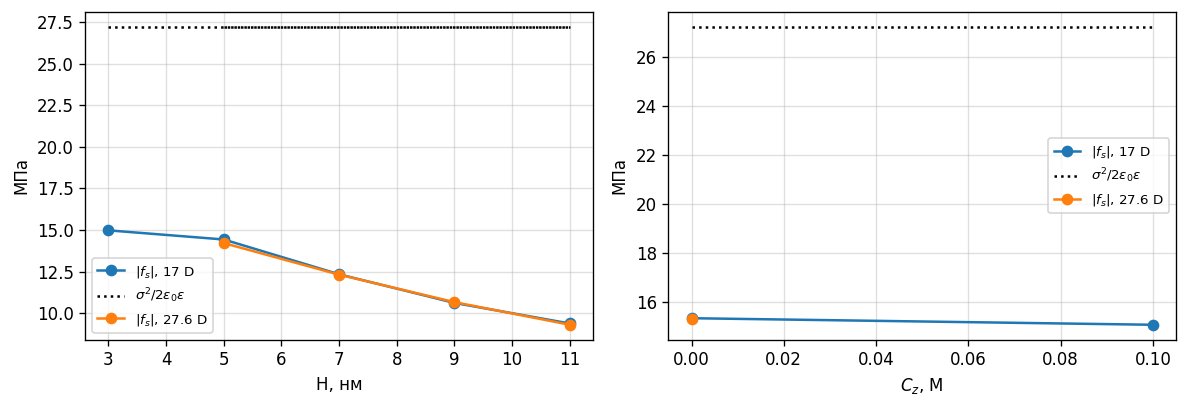

In [10]:
fig, axes = plt.subplots(1, 2, figsize=(10, 3.5), dpi=120)
for ax, sweep in zip(axes, ["H", "Cz"]):
    for pz in PZ_DIRS.values():
        g = table[(table.sweep == sweep) & (table.pz == pz)].sort_values(sweep)
        if g.empty:
            continue
        ax.plot(g[sweep], np.abs(g.f_s), "o-", color=COLORS[pz], label=fr"$|f_s|$, {pz:g} D")
        ax.plot(g[sweep], g.p_smeared, "k:", label=r"$\sigma^2/2\varepsilon_0\varepsilon$" if pz == 17.0 else None)
    ax.set_xlabel(XLAB[sweep]); ax.set_ylabel("МПа"); ax.grid(alpha=0.4); ax.legend(fontsize=8)
plt.tight_layout(); plt.show()
